In [380]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def load_data(file_path, grandlabels):
    data = pd.read_csv(file_path, header=None)
    # Assign column names ["sepal length","sepal width","petal length","petal width","family"]
    data.columns = grandlabels
    return data

grandlabels = ["sepal length", "sepal width", "petal length", "petal width", "family"]
df = load_data("iris.csv",grandlabels)
family_mapping = { "Iris-setosa": 0, "Iris-virginica": 1, "Iris-versicolor": 2 }
df_family = df['family'].map(family_mapping)
df = df[["sepal length", "sepal width", "petal length", "petal width"]]
#print(df[df["family"]==1])


In [381]:
nparr = df.to_numpy()

In [382]:
mu = nparr.mean(0)
mu


array([5.84333333, 3.05733333, 3.758     , 1.19933333])

In [383]:
Dc = nparr - mu


In [384]:
Dc.shape[0]

#np.dot(Dc.T, Dc)

150

In [385]:
#Dc.sum(0)
C = np.dot(Dc.T, Dc)/Dc.shape[0]
C

array([[ 0.68112222, -0.04215111,  1.26582   ,  0.51282889],
       [-0.04215111,  0.18871289, -0.32745867, -0.12082844],
       [ 1.26582   , -0.32745867,  3.09550267,  1.286972  ],
       [ 0.51282889, -0.12082844,  1.286972  ,  0.57713289]])

In [386]:
s, U = np.linalg.eigh(C)
s


array([0.02367619, 0.0776881 , 0.24105294, 4.20005343])

In [387]:
U

array([[ 0.31548719,  0.58202985,  0.65658877, -0.36138659],
       [-0.3197231 , -0.59791083,  0.73016143,  0.08452251],
       [-0.47983899, -0.07623608, -0.17337266, -0.85667061],
       [ 0.75365743, -0.54583143, -0.07548102, -0.3582892 ]])

In [388]:
P = U[:, ::-1][:, 0:2]
P


array([[-0.36138659,  0.65658877],
       [ 0.08452251,  0.73016143],
       [-0.85667061, -0.17337266],
       [-0.3582892 , -0.07548102]])

In [389]:
v,s,vT = np.linalg.svd(C)


In [ ]:
P = v[:,:2]
print(P)
P[:,1] = - P[:,1]
print(P)
print(Dc)

def compute_PCA(P,Dc):
    return Dc @ P



[[-0.36138659 -0.65658877]
 [ 0.08452251 -0.73016143]
 [-0.85667061  0.17337266]
 [-0.3582892   0.07548102]]
[[-7.43333333e-01  4.42666667e-01 -2.35800000e+00 -9.99333333e-01]
 [-9.43333333e-01 -5.73333333e-02 -2.35800000e+00 -9.99333333e-01]
 [-1.14333333e+00  1.42666667e-01 -2.45800000e+00 -9.99333333e-01]
 [-1.24333333e+00  4.26666667e-02 -2.25800000e+00 -9.99333333e-01]
 [-8.43333333e-01  5.42666667e-01 -2.35800000e+00 -9.99333333e-01]
 [-4.43333333e-01  8.42666667e-01 -2.05800000e+00 -7.99333333e-01]
 [-1.24333333e+00  3.42666667e-01 -2.35800000e+00 -8.99333333e-01]
 [-8.43333333e-01  3.42666667e-01 -2.25800000e+00 -9.99333333e-01]
 [-1.44333333e+00 -1.57333333e-01 -2.35800000e+00 -9.99333333e-01]
 [-9.43333333e-01  4.26666667e-02 -2.25800000e+00 -1.09933333e+00]
 [-4.43333333e-01  6.42666667e-01 -2.25800000e+00 -9.99333333e-01]
 [-1.04333333e+00  3.42666667e-01 -2.15800000e+00 -9.99333333e-01]
 [-1.04333333e+00 -5.73333333e-02 -2.35800000e+00 -1.09933333e+00]
 [-1.54333333e+00 -5

0      0
1      0
2      0
3      0
4      0
      ..
145    1
146    1
147    1
148    1
149    1
Name: family, Length: 150, dtype: int64


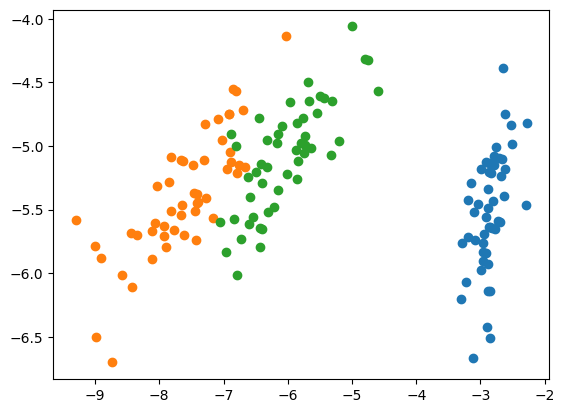

In [391]:
y = compute_PCA(P,nparr)

print(df_family)
df_reduced = pd.concat([pd.DataFrame(y,columns=['a','b']),df_family],axis=1)

fig, ax = plt.subplots()
for family in range(0,3):
    ax.scatter(df_reduced[df_reduced['family']==family]["a"],df_reduced[df_reduced['family']==family]["b"],label = family)
plt.show()


0      0
1      0
2      0
3      0
4      0
      ..
145    1
146    1
147    1
148    1
149    1
Name: family, Length: 150, dtype: int64


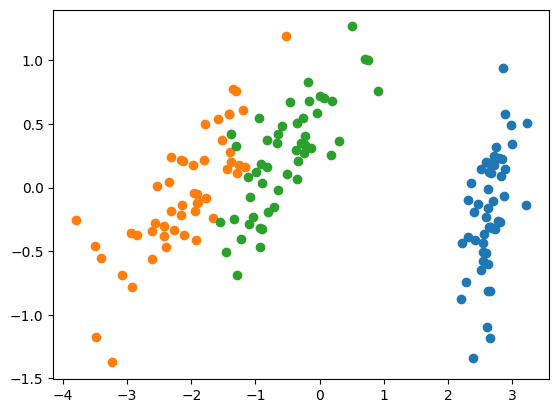

In [392]:
y = compute_PCA(P,Dc)

print(df_family)
df_reduced = pd.concat([pd.DataFrame(y,columns=['a','b']),df_family],axis=1)

fig, ax = plt.subplots()
for family in range(0,3):
    ax.scatter(df_reduced[df_reduced['family']==family]["a"],df_reduced[df_reduced['family']==family]["b"],label = family)
plt.show()